# Import the necessary Libraries

In [1]:
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")
%env PYTHONWARNINGS=ignore
%env JUPYTER_PLATFORM_DIRS=1

env: PYTHONWARNINGS=ignore
env: JUPYTER_PLATFORM_DIRS=1


In [2]:
import time

from google import genai

# For extracting vertex experiment details.
from google.cloud import aiplatform
from google.cloud.aiplatform.metadata import context
from google.cloud.aiplatform.metadata import utils as metadata_utils
from google.genai import types

# For data handling.
import jsonlines
import pandas as pd
from sklearn.model_selection import train_test_split

# For loading the dataset.
from feast import FeatureStore

# For visualization.
import matplotlib.pyplot as plt

# For fine tuning Gemini model.
import vertexai

# Set Google Cloud project information and initialize Vertex AI and Gen AI SDK

In [3]:
PROJECT_ID = "arcane-rigging-461217-m1"  
REGION = "us-central1" 
BUCKET_URI = "gs://mlops-course-arcane-rigging-461217-m1/finetuning-datasets/"
base_model = "gemini-2.5-flash-lite"
tuned_model_display_name = "Iris-tuned-model"
train_file = "iris_train_samples.jsonl"
val_file = "iris_val_samples.jsonl"

In [4]:
vertexai.init(project=PROJECT_ID, location=REGION)
client = genai.Client(vertexai=True, project=PROJECT_ID, location=REGION)

# Create Dataset in correct format

In [5]:
# Initialize the Feast feature store
# This connects to the pre-configured feature repository
store = FeatureStore(repo_path="Iris_Feast/feature_repo")

/home/jupyter/assignment/.env/lib/python3.12/site-packages/feast/repo_config.py:268: DeprecationWarning: The serialization version 2 and below will be deprecated in the next release. Specifying `entity_key_serialization_version` to 3 is recommended.
  warnings.warn(


In [6]:
# Load entity dataframe with timestamps for historical feature retrieval
entity_df = pd.read_csv("data/entity.csv", parse_dates=['event_timestamp'])

# Retrieve historical features using Feast
# This gets features at specific points in time for training
data = store.get_historical_features(
    entity_df=entity_df,
    features=store.get_feature_service("feast_model_v1")
).to_df()

In [7]:
def convert_to_categorical_bins(data):
    """
    Convert numerical features to categorical bins (low, medium, high)
    
    Parameters:
    data: DataFrame with columns 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'
    
    Returns:
    DataFrame with numerical features converted to categorical bins
    """
    
    # Create a copy to avoid modifying original data
    binned_data = data.copy()
    
    # Define the numerical features to bin
    numerical_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    
    # Convert each numerical feature to categorical bins
    for feature in numerical_features:
        # Use quantile-based binning (33rd and 67th percentiles)
        binned_data[feature] = pd.cut(
            data[feature], 
            bins=3, 
            labels=['low', 'medium', 'high'],
            include_lowest=True
        )
    
    return binned_data

In [8]:
# Prepare the dataset with the required columns
data = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']]
binned_data = convert_to_categorical_bins(data)
binned_data.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,low,high,low,low,setosa
1,low,medium,low,low,setosa
2,low,high,low,low,setosa
3,low,low,low,low,setosa
4,low,medium,low,low,setosa
5,low,medium,low,low,setosa
6,low,high,low,low,setosa
7,low,medium,low,low,setosa
8,low,medium,low,low,setosa
9,low,medium,low,low,setosa


In [9]:
# Split data into training and validation sets
val_size = 0.2 # 20% of the data for validation
train, val = train_test_split(
    binned_data, 
    test_size=val_size, 
    stratify=data['species'],  # Maintain class proportions
    random_state=42  # For reproducible results
)

In [10]:
def create_flower_description(row):
    """
    Create a textual description of the flower based on binned features
    """
    description = (
        f"This flower has {row['sepal_length']} sepal length, "
        f"{row['sepal_width']} sepal width, "
        f"{row['petal_length']} petal length, and "
        f"{row['petal_width']} petal width."
    )
    return description

In [10]:
system_prompt = "Classify the given flower using its description into one of these three classes: [Setosa, Virginica, Versicolor]. Give a single word output."

In [12]:
def create_tuning_samples(binned_data):
    """
    Convert binned data to the specified JSON format for each row
    """
    examples = []
    
    for idx, row in binned_data.iterrows():
        # Create textual description
        flower_description = create_flower_description(row)
        
        # Get the species name
        species_name = row['species']
        
        # Create the JSON structure for this example
        example = {
            "systemInstruction": {
                "parts": [
                    {
                        "text": system_prompt
                    }
                ]
            },
            "contents": [
                {
                    "role": "user",
                    "parts": [
                        {
                            "text": flower_description
                        }
                    ]
                },
                {
                    "role": "model", 
                    "parts": [
                        {
                            "text": species_name
                        }
                    ]
                }
            ]
        }
        
        examples.append(example)
    
    return examples

In [13]:
def save_jsonlines(file, instances):
    """
    Saves a list of json instances to a jsonlines file.
    """
    with jsonlines.open(file, mode="w") as writer:
        writer.write_all(instances)

In [14]:
train_instances = create_tuning_samples(train)
print(f"The number of training instances: {len(train_instances)}")
print(f"\nExample: {train_instances[0]}")

The number of training instances: 117

Example: {'systemInstruction': {'parts': [{'text': 'Classify the given flower using its description into one of these three classes: [Setosa, Virginica, Versicolor]. Give a single word output.'}]}, 'contents': [{'role': 'user', 'parts': [{'text': 'This flower has medium sepal length, medium sepal width, medium petal length, and high petal width.'}]}, {'role': 'model', 'parts': [{'text': 'versicolor'}]}]}


In [15]:
# save the training instances to jsonl file
save_jsonlines(f"data/{train_file}", train_instances)

In [16]:
val_instances = create_tuning_samples(val)
print(f"The number of validation instances: {len(val_instances)}")
print(f"\nExample: {val_instances[0]}")

The number of validation instances: 30

Example: {'systemInstruction': {'parts': [{'text': 'Classify the given flower using its description into one of these three classes: [Setosa, Virginica, Versicolor]. Give a single word output.'}]}, 'contents': [{'role': 'user', 'parts': [{'text': 'This flower has medium sepal length, medium sepal width, medium petal length, and medium petal width.'}]}, {'role': 'model', 'parts': [{'text': 'versicolor'}]}]}


In [17]:
# save the validation instances to jsonl file
save_jsonlines(f"data/{val_file}", val_instances)

In [18]:
# Copy the tuning and evaluation data to the bucket.
!gsutil cp data/{train_file} {BUCKET_URI}
!gsutil cp data/{val_file} {BUCKET_URI}

/home/jupyter/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=25045) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Copying file://data/iris_train_samples.jsonl [Content-Type=application/octet-stream]...
/ [1 files][ 45.0 KiB/ 45.0 KiB]                                                
Operation completed over 1 objects/45.0 KiB.                                     
Copying file://data/iris_val_samples.jsonl [Content-Type=application/octet-stream]...
/ [1 files][ 11.5 KiB/ 11.5 KiB]                                                
Operation completed over 1 objects/11.5 KiB.                                     


# Evaluation before model tuning

In [5]:
def load_jsonl_file(filename):
    """
    Load all data from a JSONL file into a list
    """
    data = []
    with jsonlines.open(filename) as reader:
        for obj in reader:
            data.append(obj)
    return data

In [6]:
def validated_response(response):
    expected_species = {'setosa', 'versicolor', 'virginica'}
    species_predicted = response.candidates[0].content.parts[0].text.strip().lower()
    assert species_predicted in expected_species, f"Unexpected species found: {species_predicted}"
    return species_predicted

In [7]:
def check_accuracy(test_data, client, model, config):
    """
    Function to check model accuracy
    """
    correct = 0
    total = 0
    blocked = 0
    
    print("Checking accuracy...")
    
    for i, item in enumerate(test_data):
        try:
            prompt = item['contents'][0]['parts'][0]['text']
            response = client.models.generate_content(
                model=model,
                contents=prompt,
                config=config,
            )
            
            # Check if response is blocked
            if not (
                response
                and response.candidates
                and response.candidates[0].content.parts
            ):
                print(f"Blocked response for item {i+1}")
                blocked += 1
                continue
            
            # Get prediction and true label
            prediction = validated_response(response)
            true_label = item['contents'][1]['parts'][0]['text'].strip().lower()
            # Check if correct
            if prediction == true_label:
                correct += 1
            
            total += 1
            
            time.sleep(10)
                
        except Exception as e:
            print(f"Error with item {i+1}: {e}")
            continue
    
    # Calculate final accuracy
    accuracy = correct / total if total > 0 else 0
    
    # Print results
    print(f"RESULTS:")
    print(f"Accuracy: {accuracy:.2%} ({correct}/{total})")
    print(f"Blocked responses: {blocked}")
    print(f"Total processed: {total + blocked}")
    
    return accuracy

In [8]:
val_instances = load_jsonl_file(f"data/{val_file}")

In [11]:
config = types.GenerateContentConfig(
    system_instruction=[system_prompt],
    temperature=0.1,
    max_output_tokens=2
    )

prompt = val_instances[0]['contents'][0]['parts'][0]['text']

client.models.generate_content(model=base_model,contents=prompt,config=config).text

'Versicolor'

In [12]:
base_accuracy = check_accuracy(val_instances, client, base_model, config)

Checking accuracy...
RESULTS:
Accuracy: 86.67% (26/30)
Blocked responses: 0
Total processed: 30


# Fine-tune the Model

In [27]:
training_dataset = {
    "gcs_uri": f"{BUCKET_URI}{train_file}",
}

validation_dataset = types.TuningValidationDataset(
    gcs_uri=f"{BUCKET_URI}{val_file}"
)

# Tune a model using `tune` method.
sft_tuning_job = client.tunings.tune(
    base_model=base_model,
    training_dataset=training_dataset,
    config=types.CreateTuningJobConfig(
        tuned_model_display_name=tuned_model_display_name,
        validation_dataset=validation_dataset,
    ),
)

In [28]:
tuning_job = client.tunings.get(name=sft_tuning_job.name)
tuning_job

TuningJob(
  base_model='gemini-2.5-flash-lite',
  create_time=datetime.datetime(2025, 8, 17, 19, 9, 39, 654027, tzinfo=TzInfo(UTC)),
  name='projects/582595595554/locations/us-central1/tuningJobs/4955188105373024256',
  sdk_http_response=HttpResponse(
    headers=<dict len=9>
  ),
  start_time=datetime.datetime(2025, 8, 17, 19, 9, 39, 708938, tzinfo=TzInfo(UTC)),
  state=<JobState.JOB_STATE_RUNNING: 'JOB_STATE_RUNNING'>,
  supervised_tuning_spec=SupervisedTuningSpec(
    training_dataset_uri='gs://mlops-course-arcane-rigging-461217-m1/finetuning-datasets/iris_train_samples.jsonl',
    validation_dataset_uri='gs://mlops-course-arcane-rigging-461217-m1/finetuning-datasets/iris_val_samples.jsonl'
  ),
  tuned_model_display_name='Iris-tuned-model',
  update_time=datetime.datetime(2025, 8, 17, 19, 9, 40, 476178, tzinfo=TzInfo(UTC))
)

In [29]:
%%time
# Wait for job completion

running_states = [
    "JOB_STATE_PENDING",
    "JOB_STATE_RUNNING",
]

while tuning_job.state.name in running_states:
    print(".", end="")
    tuning_job = client.tunings.get(name=tuning_job.name)
    time.sleep(10)
print()

...............

..........................................................................................................
CPU times: user 1.1 s, sys: 121 ms, total: 1.22 s
Wall time: 23min 20s


In [30]:
tuned_model = tuning_job.tuned_model.endpoint
experiment_name = tuning_job.experiment

print("Tuned model experiment", experiment_name)
print("Tuned model endpoint resource name:", tuned_model)

Tuned model experiment projects/582595595554/locations/us-central1/metadataStores/default/contexts/tuning-experiment-20250817121207034749
Tuned model endpoint resource name: projects/582595595554/locations/us-central1/endpoints/7707280742081888256


In [13]:
tuned_model = "projects/582595595554/locations/us-central1/endpoints/7707280742081888256"

# Tuning and evaluation metrics

In [31]:
# Locate Vertex AI Experiment and Vertex AI Experiment Run
experiment = aiplatform.Experiment(experiment_name=experiment_name)
filter_str = metadata_utils._make_filter_string(
    schema_title="system.ExperimentRun",
    parent_contexts=[experiment.resource_name],
)
experiment_run = context.Context.list(filter_str)[0]

In [32]:
# Read data from Tensorboard
tensorboard_run_name = f"{experiment.get_backing_tensorboard_resource().resource_name}/experiments/{experiment.name}/runs/{experiment_run.name.replace(experiment.name, '')[1:]}"
tensorboard_run = aiplatform.TensorboardRun(tensorboard_run_name)
metrics = tensorboard_run.read_time_series_data()

In [33]:
def get_metrics(metric: str = "/train_total_loss"):
    """
    Get metrics from Tensorboard.

    Args:
      metric: metric name, eg. /train_total_loss or /eval_total_loss.
    Returns:
      steps: list of steps.
      steps_loss: list of loss values.
    """
    loss_values = metrics[metric].values
    steps_loss = []
    steps = []
    for loss in loss_values:
        steps_loss.append(loss.scalar.value)
        steps.append(loss.step)
    return steps, steps_loss

In [34]:
# Get Train and Eval Loss
train_loss = get_metrics(metric="/train_total_loss")
eval_loss = get_metrics(metric="/eval_total_loss")

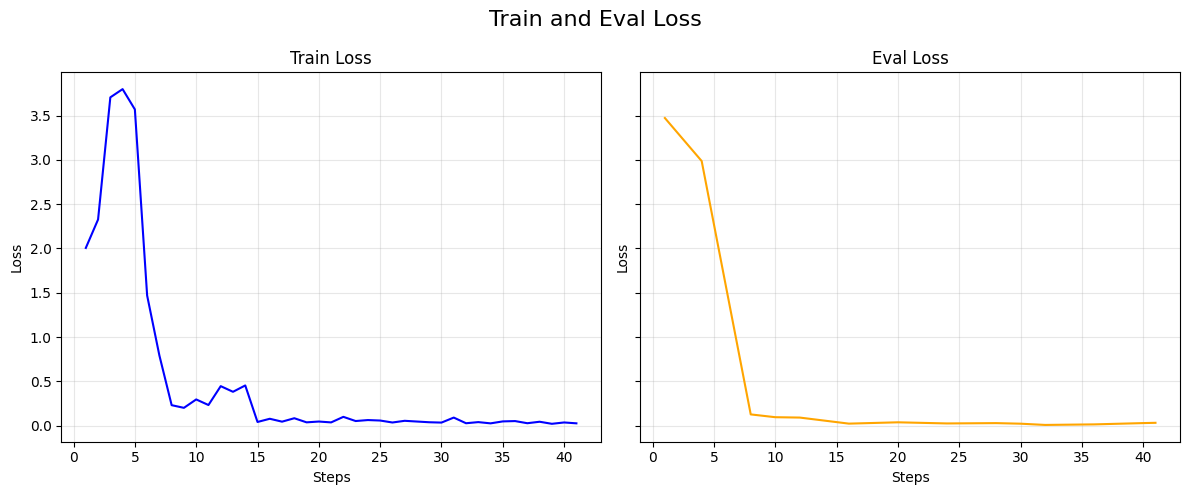

In [35]:
# Create subplots with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot train loss
ax1.plot(train_loss[0], train_loss[1], label="Train Loss", color='blue')
ax1.set_title("Train Loss")
ax1.set_xlabel("Steps")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# Plot eval loss
ax2.plot(eval_loss[0], eval_loss[1], label="Eval Loss", color='orange')
ax2.set_title("Eval Loss")
ax2.set_xlabel("Steps")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

# Add main title
fig.suptitle("Train and Eval Loss", fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plot
plt.show()

In [14]:
client.models.generate_content(model=tuned_model, contents=prompt, config=config).text

'versicolor'

In [15]:
tuned_accuracy = check_accuracy(val_instances, client, tuned_model, config)

Checking accuracy...
RESULTS:
Accuracy: 96.67% (29/30)
Blocked responses: 0
Total processed: 30


In [16]:
# Calculate improvements
absolute_improvement = tuned_accuracy - base_accuracy
relative_improvement = (absolute_improvement / base_accuracy) * 100 if base_accuracy > 0 else 0
print(f"Relative Improvement: {relative_improvement:.1f}%")

Relative Improvement: 11.5%
